In [20]:
#a)
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
df=sns.load_dataset("tips")
print(df.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [13]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


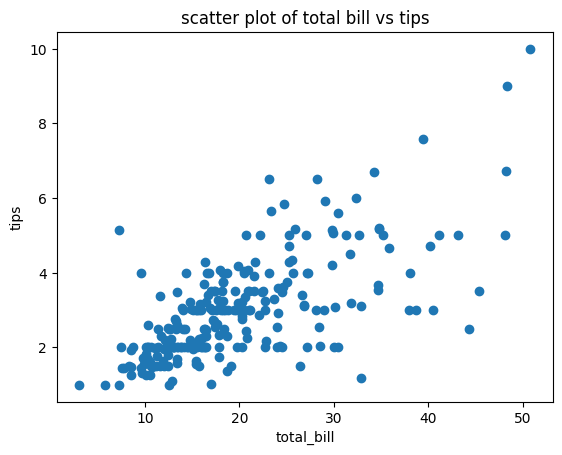

In [28]:
#b)
plt.scatter(df.total_bill,df.tip)
plt.xlabel("total_bill")
plt.ylabel("tips")
plt.title("scatter plot of total bill vs tips")
plt.savefig("scatterplot")
plt.show()

Text(0.5, 0, 'total_bill')

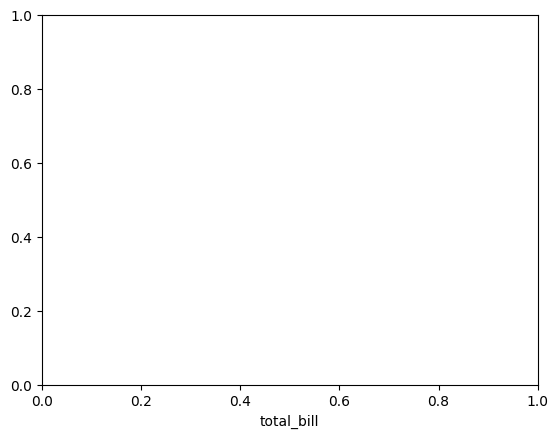

In [23]:
plt.xlabel("total_bill")


In [31]:
import statsmodels.api as sm

ModuleNotFoundError: No module named 'statsmodels'

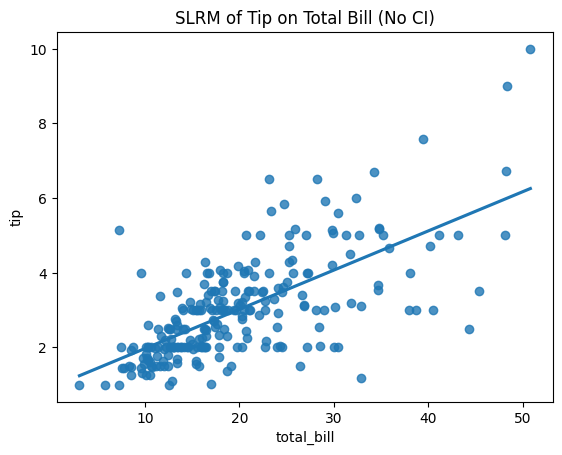

In [62]:
sns.regplot(x="total_bill", y="tip", data=df, ci=None)

plt.title("SLRM of Tip on Total Bill (No CI)")
plt.show()

In [40]:
model.params

const         0.920270
total_bill    0.105025
dtype: float64

In [42]:
#d)
b0 = model.params["const"]
b1 = model.params["total_bill"]

print(b0, b1)


0.9202696135546737 0.10502451738435337


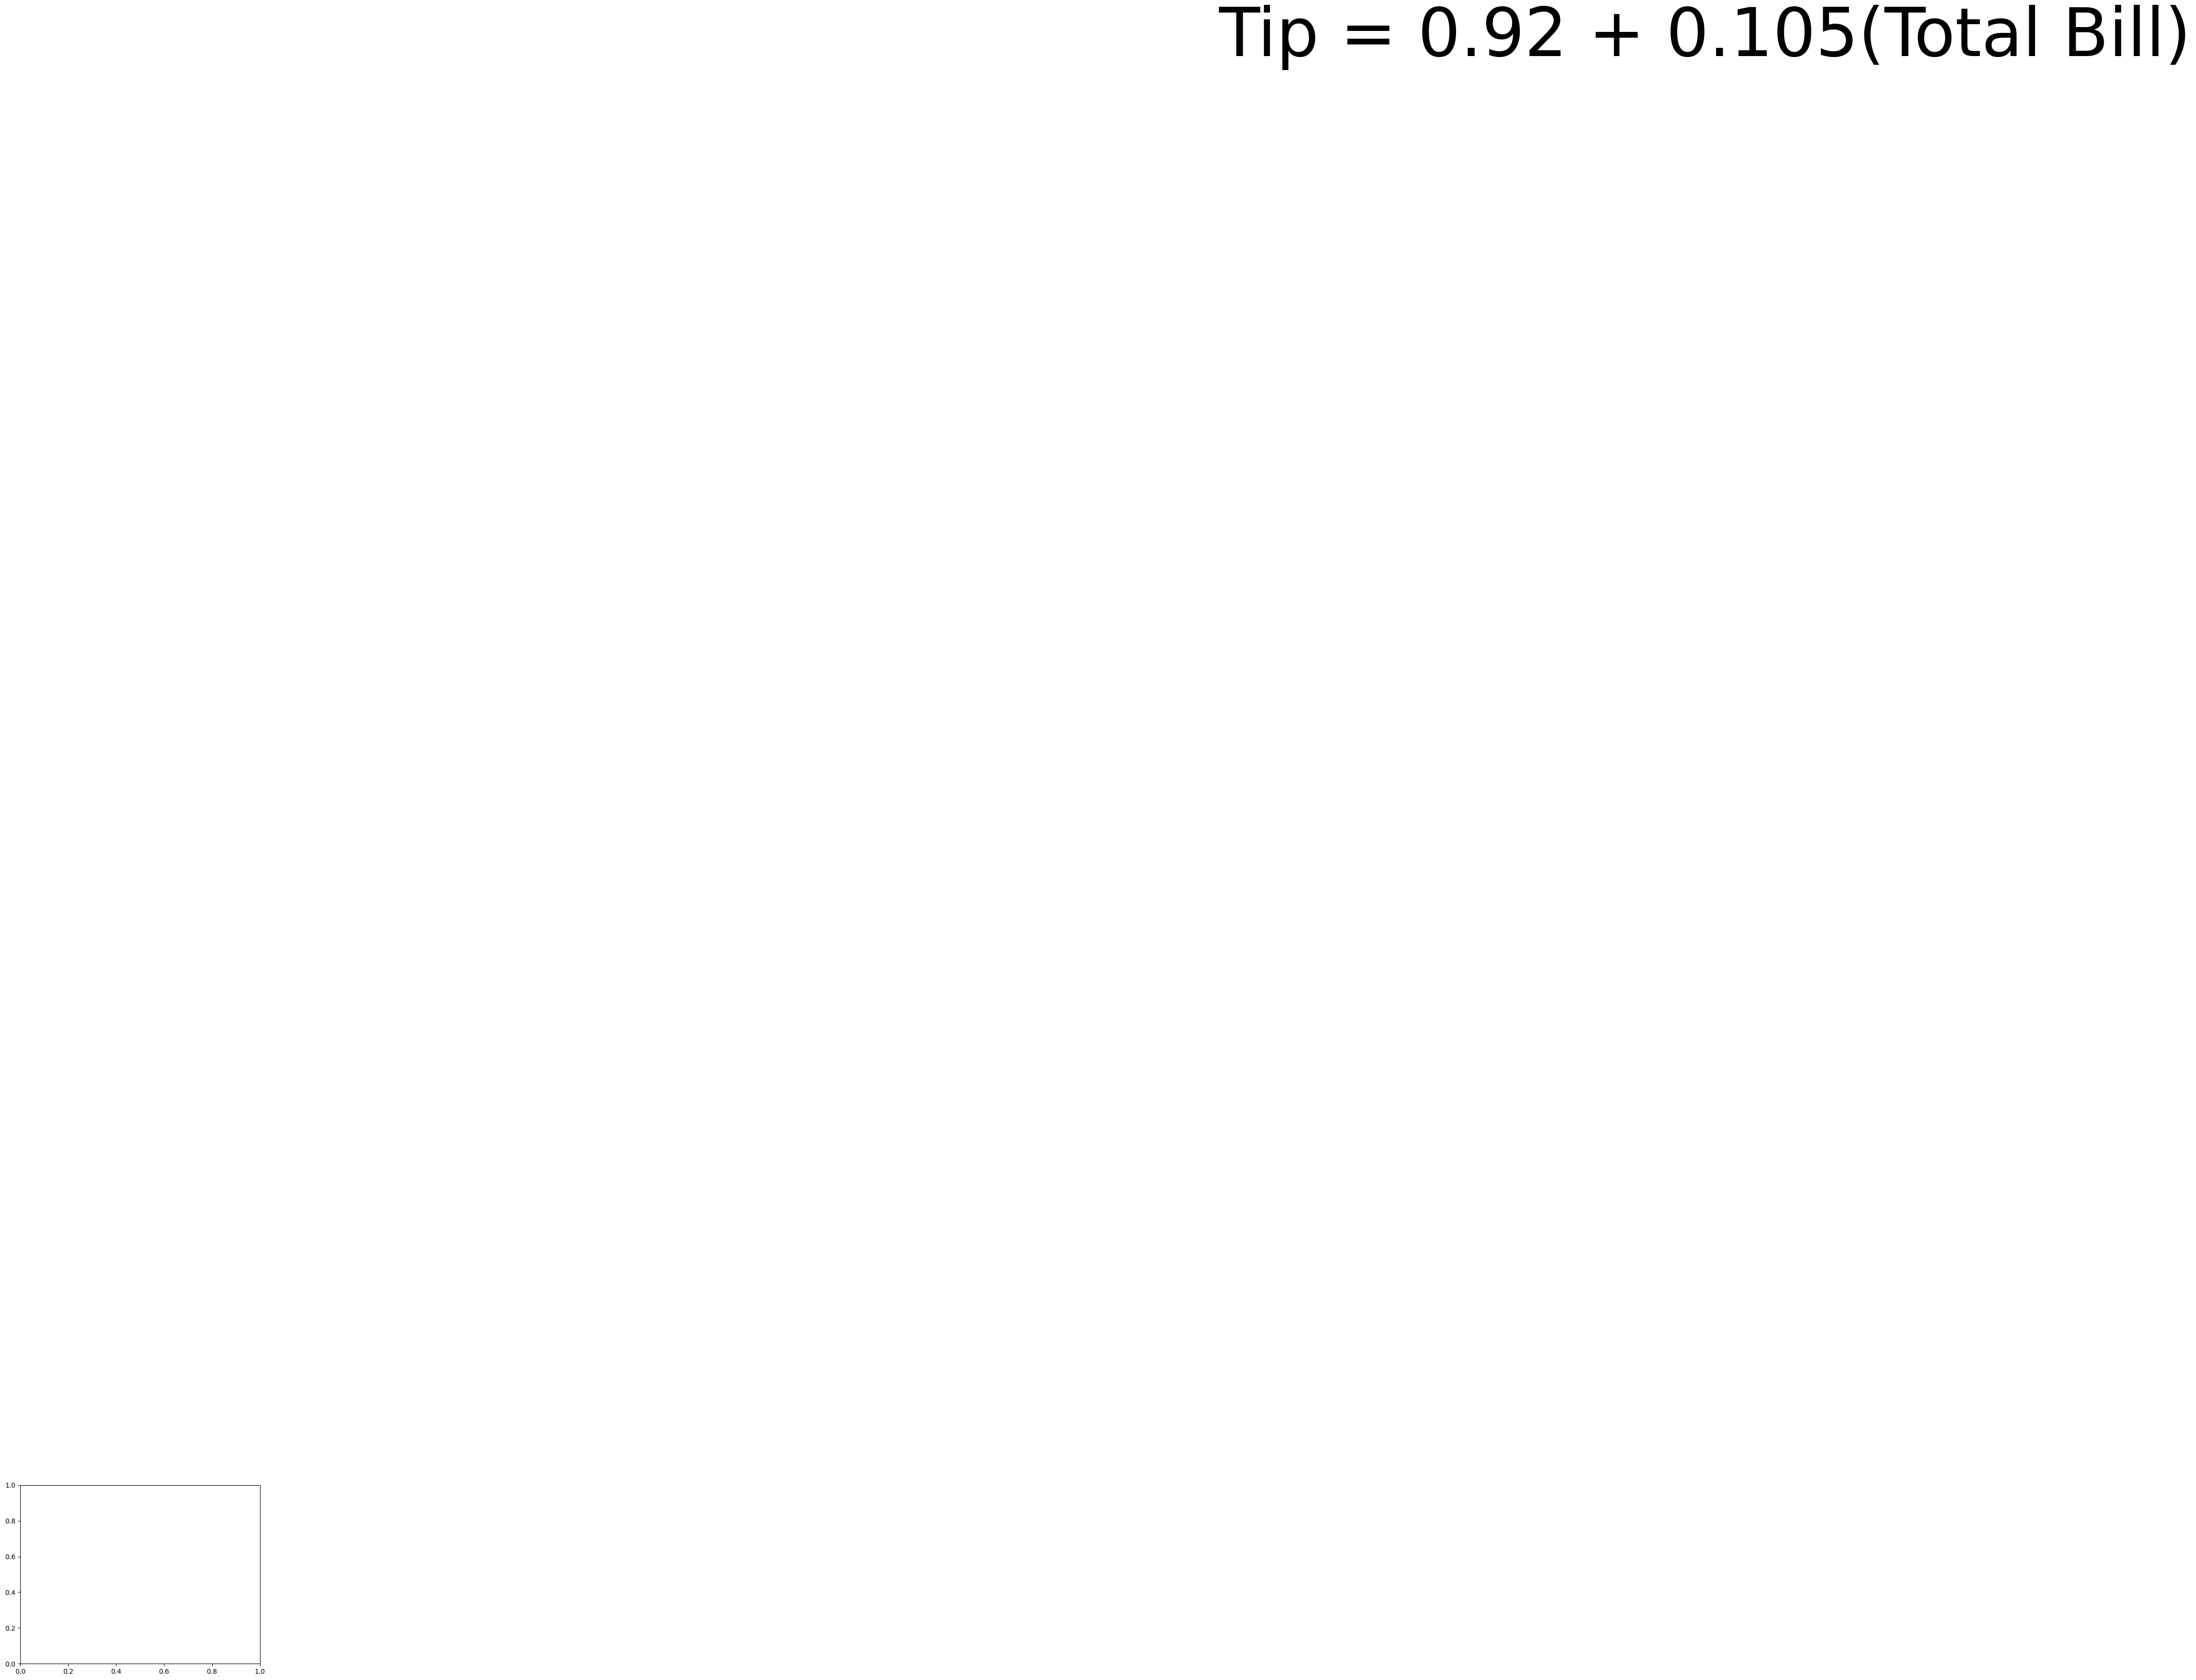

Tip = 0.92027 + 0.10502(Total Bill)


In [48]:
plt.text(5, 9,
         f"Tip = {b0:.2f} + {b1:.3f}(Total Bill)",
         fontsize=100)

plt.show()
#or
print(f"Tip = {b0:.5f} + {b1:.5f}(Total Bill)")

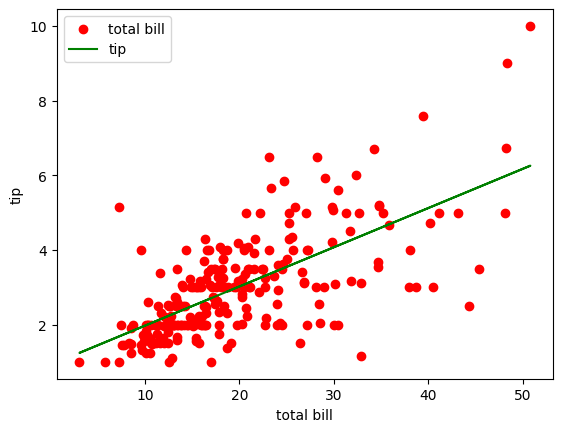

In [61]:
#g)
model.predict(X)
plt.scatter(df.total_bill,df.tip,color="r",label="total bill")
plt.plot(df.total_bill,model.predict(X),color="g",label="tip")
plt.xlabel("total bill")
plt.ylabel("tip")
plt.legend()
plt.show()

In [65]:
print(f"coeficent of determination: {model.rsquared:.4f}")

coeficent of determination: 0.4566


In [66]:
#h)
Y_hat=model.predict(X)
Resi=Y-Y_hat

<function matplotlib.pyplot.show(close=None, block=None)>

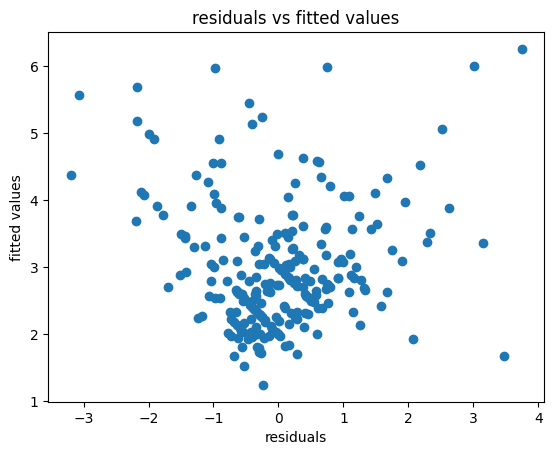

In [68]:
plt.scatter(Resi,Y_hat)
plt.xlabel("residuals")
plt.ylabel("fitted values")
plt.title("residuals vs fitted values")
plt.show

(array([ 2.,  0.,  8.,  8., 18., 39., 62., 47., 26., 16.,  6.,  6.,  2.,
         2.,  2.]),
 array([-3.19822452, -2.73544724, -2.27266996, -1.80989268, -1.34711541,
        -0.88433813, -0.42156085,  0.04121643,  0.50399371,  0.96677099,
         1.42954827,  1.89232554,  2.35510282,  2.8178801 ,  3.28065738,
         3.74343466]),
 <BarContainer object of 15 artists>)

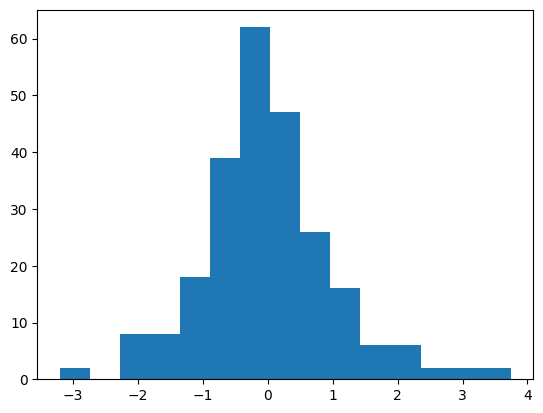

In [71]:
#i)
plt.hist(Resi,bins=15)

<function matplotlib.pyplot.show(close=None, block=None)>

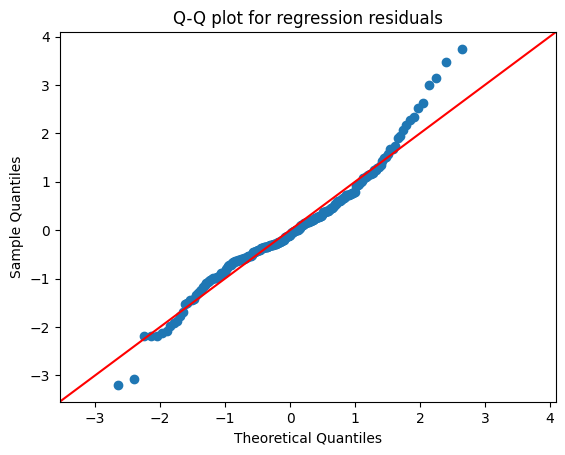

In [74]:
#j)
sm.qqplot(Resi,line="45")
plt.title("Q-Q plot for regression residuals")
plt.show

In [83]:
#K)
from scipy.stats import shapiro

stat, p_value = shapiro(Resi)

print("Shapiro-Wilk Test Statistic:", stat)
print("p-value:", p_value)

#or

import scipy.stats as ss
norm_stats, norm_pval=ss.shapiro(Resi)
alpha=0.5
if norm_pval<alpha:
    print("reject Ho: resi doesn't follow normal")
else:
    print("Fail to reject Ho: resi  follow normal") 


Shapiro-Wilk Test Statistic: 0.9672804064016668
p-value: 2.17137985424342e-05
reject Ho: resi doesn't follow normal


AndersonResult(statistic=np.float64(2.4067908866601613), critical_values=array([0.567, 0.646, 0.775, 0.904, 1.075]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(-1.8928392550986274e-16), scale=np.float64(1.0199425947107272))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')

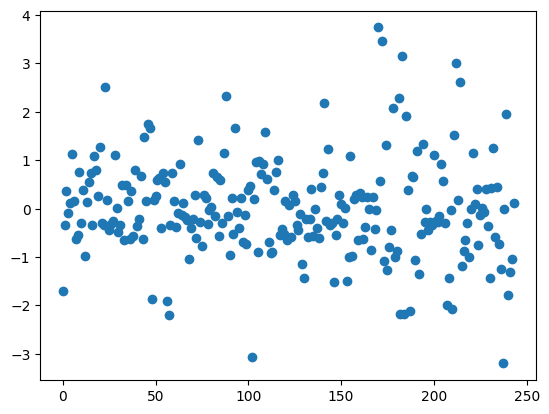

In [89]:
#L)
plt.scatter(df.index,Resi)